Generative GPU Images with Julia
==================================

## Enabling features of `GPUCompiler` / `CUDA.jl`:
- Seamless `isbits` `struct` support
  - e.g. `ColorTypes` & `GeometryBasics`
- Higher Order GPU kernels 
- Parameterized singleton types per closure  (parameterized by the types of the closed-over values )
  - e.g. `typeof(a_closure) = var"#3#4"{Int64, Int64, RGB{FixedPointNumbers.N0f8}}`
  
## Thesis  
- Leads to highly expressive definitions
   - e.g functional style: <p/> 
     `twill |>  🌺(widen)(4) |>  🌺(weave)(simpleColors) |> 🌺(zoom)(center=Point(0.75n, .4n))`
   - as compared to e.g. [Shader Toy](https://www.shadertoy.com/)
- interactive environment for creating `procedural sketches`
   - "parameters" are low-ceremony
     - in comparison to e.g. `uniforms` from `GL`
   - highly responsive 
       - tweaking parameters does not force recompilation
       - melds well w/ e.g `Pluto`


In [4]:
using Images, CUDA, Colors, GeometryBasics

In [5]:
function Base.show(io::IO, mime::MIME"image/png", img::CuArray{C}) where C<:Colorant 
    Base.show(io, mime, Array(img))
end

function Base.showable(mime::MIME"image/png", img::CuArray{C}) where C<:Colorant 
    true
end

In [89]:
function generate(f, img)
    r, c = Int32.(size(img))
    i = threadIdx().x + (blockIdx().x - 1) * blockDim().x
    j = threadIdx().y + (blockIdx().y - 1) * blockDim().y
    @inbounds if i <= r && j <= c
        @inline img[i,j] = eltype(img)(f(i,j,r,c))
    end
    return
end

generate (generic function with 1 method)

In [25]:
threads = 16,16
blocks(img) = cld.(size(img), threads)
nothing

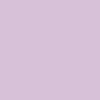

In [90]:
let 
    simple(i,j,r,c) = colorant"thistle"
    n = 50
    b = CuArray{RGB{Float32}}(undef, n,n)
    @sync @cuda threads=threads blocks=blocks(b) generate(simple, b)
    b
end

In [91]:
function pink_plaid(i,j,r,c)
        threadCount= r ÷ 2
    
        thread = mod(i-j,4) < 2           ? i % threadCount      : j % threadCount ## 2/2 twill
        thread = thread > threadCount ÷ 2 ? threadCount - thread : thread          ## symmetrize
        color  = thread < 0.2*threadCount ? colorant"pink" : 
                 thread < 0.3*threadCount ? colorant"yellow"     :                 
                                            colorant"gray"                    
end

pink_plaid (generic function with 1 method)

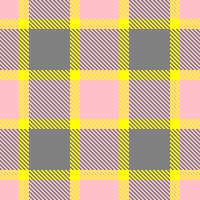

In [92]:
let 
    n = 200
    img = CuArray{RGB{Float32}}(undef, n,n)
    @sync @cuda threads=threads blocks=blocks(img) generate(pink_plaid, img)
    img
end
    

In [93]:
using BenchmarkTools
let 
    n = 200
    img = CuArray{RGB{Float32}}(undef, n,n)
    @benchmark @sync @cuda threads=threads blocks=blocks($img) generate(pink_plaid, $img)
end

BenchmarkTools.Trial: 10000 samples with 5 evaluations.
 Range (min … max):   6.795 μs … 537.096 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     10.238 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):    9.951 μs ±   5.357 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

       ▂▂▂▁▁▁  ▁▂▃▃▃▃▂▂▂▁▁▁▁           ▂▃▃▃▅▆███▇▅▄▄▃▂▁        ▂
  ▄▄▅▇████████████████████████▇██▇▇▇▇▇█████████████████▆▆▆█▇██ █
  6.79 μs       Histogram: log(frequency) by time      11.5 μs <

 Memory estimate: 1.64 KiB, allocs estimate: 38.

In [164]:
## weave
function weave(isWeftOnTop::Function, color::Function; threadWidth=1.0,margin=0.10, marginColor=colorant"ghostwhite")
    (i,j,r,c) -> begin
        i = i+0.5; j = j+0.5;  ##  №, I am not ☆ about this ❆
        (weftId, weftRem)  = divrem(i,threadWidth)
        (warpId, warpRem)  = divrem(j,threadWidth)            
        weftOnTop = isWeftOnTop(weftId, warpId) 
        remainder = weftOnTop ? weftRem : warpRem
        fraction = remainder/threadWidth
        fraction = fraction >= 0.5 ? 1.0-fraction : fraction ## symmetrize
        fraction >= margin ? color(weftOnTop,weftId,warpId) : marginColor  
    end
end

## zoom
function zoom(shader::Function; center=Point(20.0,20.0), radius=60.0, scale=20.0, enabled=true)
    (i,j,r,c) -> begin
        p = Point(i,j)
        s = (norm(p-center) < radius) & enabled ?  scale : 1.0
        p = center + (p-center)/s
        shader(p[1], p[2], r, c)
    end
end

simpleColors(isWeftOnTop, i, j) = isWeftOnTop ?  colorant"orangered" : colorant"lightgrey"
twill = (i,j) -> mod(i-j,4) < 2

function tartan(sett, threadcount = 100) 
    (weftOnTop, i, j) -> begin
        thread = weftOnTop                ? i % threadcount      : j % threadcount 
        thread = thread > threadcount ÷ 2 ? threadcount - thread : thread          
        return sett(2*thread/threadcount)
    end
end

function pink_yellow_grey_sett(;p=0.4, y=1.5p) 
    x -> begin
        x < p ? colorant"pink"   : 
        x < y ? colorant"yellow" :                 
                colorant"grey"
    end
end

widen(f, n) = (i,j) -> f(floor(Int, i/n), floor(Int, j/n))

function herring(n)
    (i,j) -> begin
			x = mod(i, n)
			(x <  n/2) ? mod(i-j,4) < 2 : mod(i+j,4) < 2  
		end
end

function escherDiamonds(size) 
	    (i,j) -> begin
	        op = mod(div(i,size) + div(j,size),2) == 0 ? (+) : (-)
	        mod(op(i,j),4) < 2 
	    end
end

nothing

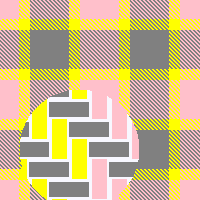

In [ ]:
let 
    n = 200
    img = CuArray{RGB{Float32}}(undef, n,n)
    shader = zoom(weave(widen(twill, 1), tartan(pink_yellow_grey_sett())); center=Point(0.75n, .4n))
    @sync @cuda threads=threads blocks=blocks(img) generate(shader, img)
    img
end

In [166]:
## functional flower power
🌺 = f -> (args...; kwargs...) -> x -> f(x, args...; kwargs...)

#344 (generic function with 1 method)

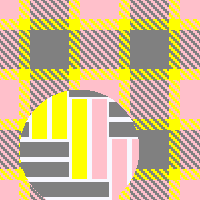

In [167]:
let 
    n = 200
    img = CuArray{RGB{Float32}}(undef, n,n)
    
    shader = twill |>  🌺(widen)(2) |>  🌺(weave)(pink_yellow_grey_sett() |> tartan) |> 
                       🌺(zoom)(center=Point(0.75n, .4n))
    
    @sync @cuda threads=threads blocks=blocks(img) generate(shader, img)
    img
end

In [168]:
let 
    n = 200
    img = CuArray{RGB{Float32}}(undef, n,n)
    shader = twill |>  🌺(widen)(2) |>  🌺(weave)(pink_yellow_grey_sett() |> tartan) |> 🌺(zoom)(center=Point(0.75n, .4n))
    @benchmark @sync @cuda threads=threads blocks=blocks($img) generate($shader, $img)
end

BenchmarkTools.Trial: 10000 samples with 1 evaluation.
 Range (min … max):  14.552 μs …  10.458 ms  ┊ GC (min … max): 0.00% … 99.16%
 Time  (median):     75.079 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   67.783 μs ± 113.046 μs  ┊ GC (mean ± σ):  1.53% ±  0.99%

                                                        ▃█▆     
  ▂▂▄▇▄▂▂▂▂▂▁▂▁▁▁▁▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▂▁▁▁▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▅████▄▃ ▃
  14.6 μs         Histogram: frequency by time         80.1 μs <

 Memory estimate: 4.86 KiB, allocs estimate: 104.

In [140]:
using Interact

In [170]:
let 
    
    img = CuArray{RGB{Float32}}(undef, 0,0)
    tw = p -> twill
    pattern = dropdown(Dict("twill"=>tw, "herring bone" => herring, "escher diamonds" => escherDiamonds), value=tw, label="pattern")
    pink =  slider(0:0.01:1, value=0.4, label="pink")
    n = slider(50:400, value=200, label="n")
    w = slider(1:5, value=2, label="widen")
    p = slider(2:20, value=10, label="pattern size")
    zi = slider(0:0.01:1, label="zoom i")
    zj = slider(0:0.01:1, label="zoom j")
    radius = slider(10:80, value=50, label="radius")
    z = checkbox(value=false, label="zoom?")
    reactive_img = map(pattern, pink, n,w, p, z, zi, zj, radius) do pattern, pink, n, w, p, z, zi, zj, radius
       img = (n,n) == size(img) ? img :  CuArray{RGB{Float32}}(undef, n,n)
       
       shader = pattern(p) |>  🌺(widen)(w) |>  
                               🌺(weave)(pink_yellow_grey_sett(p=pink) |> tartan) |>
                               🌺(zoom)(center=Point(zi*n, zj*n), radius=radius, enabled=z) 
        
       elapsed = CUDA.@timed @cuda threads=threads blocks=blocks(img) generate(shader, img)
       vbox(img,"$(round(1.0/elapsed.time, digits=1)) FPS") 
    end
    vbox(hbox(pattern,pink), 
         hbox(n,w, p),
         hbox(z, zi, zj, radius), 
         reactive_img)
end

(div { style=Dict("display" => "flex", "flex-direction" => "column") }
  (div { style=Dict("display" => "flex", "flex-direction" => "row") }
    Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any["pattern", Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :select), Any[], Dict{Symbol, Any}(:attributes => Dict{Union{String, Symbol}, Any}(Symbol("data-bind") => "options : options_js, value : index, optionsText: 'key', optionsValue: 'val', valueAllowUnset: true, optionsAfterRender: disablePlaceholder")))], Dict{Symbol, Any}(:className => "select "))], Dict{Symbol, Any}(:style => Dict("display" => "flex", "flex-direction" => "column"))), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("options_js" => (Observable(OrderedDict[OrderedDict{String, Any}("key" => "escher diamonds", "val" => 1, "id" => "idP2A2492n"), OrderedDict{String, Any}("key" => "herring bone", "val" => 2, "id" => "idGvV3LPO0"), OrderedDict{String, Any}("key" => "twill", "val" => 3, "id" => "idqPOMuM30")]), nothing), "index" => (Observable{Any}(3), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "/home/ec2-user/.julia/packages/Knockout/HReiN/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/home/ec2-user/.julia/packages/Knockout/HReiN/src/../assets/knockout_punches.js"), Asset("js", nothing, "/home/ec2-user/.julia/packages/InteractBase/Qhvxg/src/../assets/all.js"), Asset("css", nothing, "/home/ec2-user/.julia/packages/InteractBase/Qhvxg/src/../assets/style.css"), Asset("css", nothing, "/home/ec2-user/.julia/packages/Interact/PENUy/src/../assets/bulma_confined.min.css")], Dict{Any, Any}("options_js" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"options_js\"]()) ? (this.valueFromJulia[\"options_js\"]=true, this.model[\"options_js\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Condition(Base.InvasiveLinkedList{Task}(Task (runnable) @0x00007fa4033f7b00, Task (runnable) @0x00007fa4033f7b00), Base.AlwaysLockedST(1))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"options_js\":WebIO.getval({\"name\":\"options_js\",\"scope\":\"17793473433762440457\",\"id\":\"9012372748421963558\",\"type\":\"observable\"}),\"index\":WebIO.getval({\"name\":\"index\",\"scope\":\"17793473433762440457\",\"id\":\"15310099648419870144\",\"type\":\"observable\"})};\n    var self = this;\n    function AppViewModel() {\n        for (var key in json_data) {\n            var el = json_data[key];\n            this[key] = Array.isArray(el) ? ko.observableArray(el) : ko.observable(el);\n        }\n        [this[\"disablePlaceholder\"]=functi

### Future Topics
- I,J -> X,Y (derivatives)
- T
- Z
- noise
- games



### Issues
- Metal
  - 10x slower
  - invalid IR
  - chtulhu help


### Testing Utils

In [98]:
function generate_cpu(f, img)
    r, c = size(img)
    @Threads.threads for i=1:r
        for j=1:c
            @inbounds @inline img[i,j] = eltype(img)(f(i,j,r,c))
        end
    end
    return
end    
            

generate_cpu (generic function with 1 method)

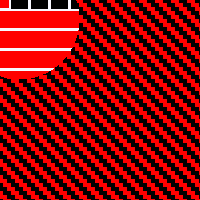

In [144]:
let 
    n = 200
    img = Array{RGB{Float32}}(undef, n,n)
    shader = zoom(weave(widen(twill, 4), simpleColors))
    generate_cpu(shader, img)
    img
end